# Artifact-Reject Demo
**HackDuke 2026 — James Mu (Duke) & Derek Mu (CMU)**

This notebook demonstrates the artifact rejection pipeline on synthetic neural signal.
No Synapse device or simulator required — everything runs locally.

### Pipeline
1. Generate synthetic neural-like broadband signal (32 channels, 30 kHz)
2. Inject real-world artifact types: spikes, flatlines, 60 Hz line noise
3. Run **our detector** (MAD + FFT) vs **industry baseline** (fixed amplitude threshold)
4. Compare precision, false positives, and visual output

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import sys
sys.path.insert(0, '../client')

from artifact_reject import (
    detect_mad, detect_60hz,
    SAMPLE_RATE_HZ, WINDOW_SAMPLES, N_CHANNELS,
)

plt.style.use('dark_background')
rng = np.random.default_rng(42)


def detect_zscore(window, threshold=5.0):
    """Baseline detector: per-channel z-score with a fixed threshold.

    Used widely in BCI and EEG preprocessing pipelines. Flags a channel if
    any sample exceeds `threshold` standard deviations from the channel mean.

    Failure modes:
      - Flatlines: std → 0, z-score undefined → silently missed
      - 60 Hz noise: artifact spreads energy across all samples, inflating σ
        and keeping peak z-scores below threshold → missed
      - Masking: broad artifacts inflate σ, reducing z-scores of the very
        samples they corrupt
    """
    flagged = []
    for ch in range(window.shape[0]):
        signal = window[ch]
        std = signal.std()
        if std == 0:
            continue  # flatline → missed
        z = np.abs(signal - signal.mean()) / std
        if np.any(z > threshold):
            flagged.append(ch)
    return len(flagged) > 0, flagged


print('Ready.')

Ready.


## 1. Generate synthetic neural signal

Real neural broadband signal is roughly Gaussian with occasional bursts.
We simulate it as band-limited Gaussian noise (0–6 kHz) to match typical spike-band recordings.

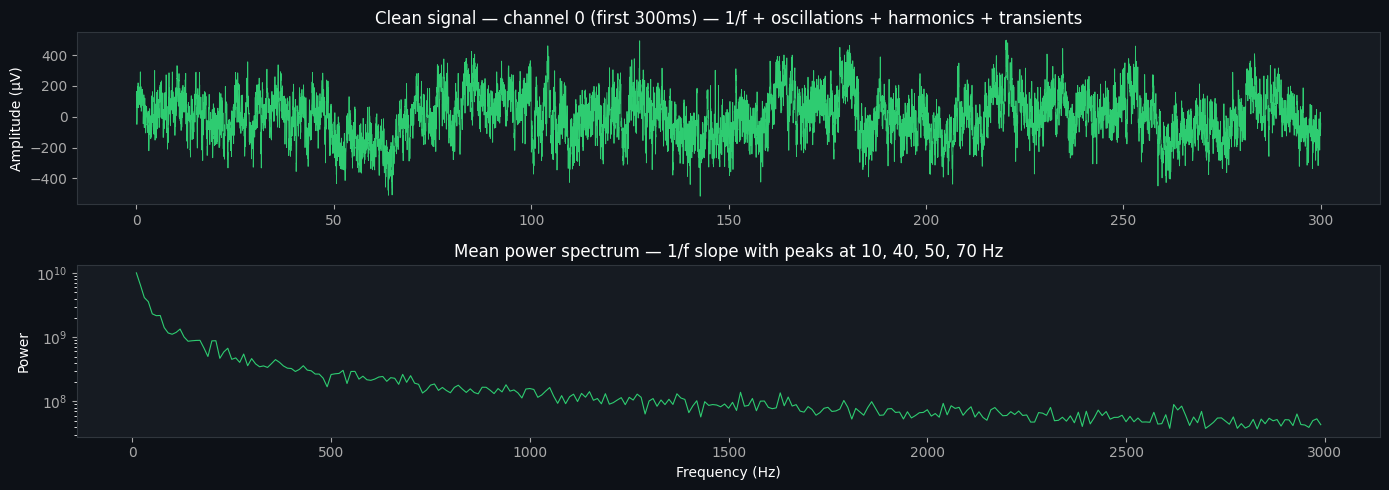

Signal stats — mean: -0.0 μV  std: 150.6 μV  max: 767.0 μV


In [2]:
N_WINDOWS   = 40
DISPLAY_CH  = 0
SIGNAL_STD  = 150   # microvolts, typical spike-band RMS

# Oscillation amplitudes (all well below artifact thresholds)
ALPHA_AMP        = 25    # μV — 10 Hz alpha rhythm
GAMMA_AMP        = 18    # μV — 40 Hz gamma rhythm
HARMONIC_AMP     = 20    # μV — 50/70 Hz harmonics (stresses the 60Hz FFT detector)
TRANSIENT_AMP    = 430   # μV — sub-threshold transients; quiet channels can push MAD close to threshold

def pink_noise(n_samples: int, rng) -> np.ndarray:
    """Generate 1/f (pink) noise via frequency-domain shaping."""
    freqs = np.fft.rfftfreq(n_samples)
    freqs[0] = 1e-6
    filt = 1.0 / np.sqrt(freqs)
    filt[0] = 0
    white = rng.normal(0, 1, n_samples)
    shaped = np.fft.irfft(np.fft.rfft(white) * filt, n=n_samples)
    return shaped / shaped.std()


def generate_clean_signal(n_windows, rng):
    """Generate N windows of realistic synthetic neural broadband signal.

    Each window (N_CHANNELS, WINDOW_SAMPLES) contains:
      - 1/f pink noise backbone scaled to SIGNAL_STD
      - Occasional alpha (10 Hz) and gamma (40 Hz) oscillatory bursts
      - 50/70 Hz harmonic noise in ~35% of windows — raises FFT neighbor bins
        near 60 Hz, making line-noise detection harder
      - Sub-threshold transients (brief spikes well below artifact threshold)
    """
    t = np.arange(WINDOW_SAMPLES) / SAMPLE_RATE_HZ

    windows = []
    for _ in range(n_windows):
        sig = np.stack([
            pink_noise(WINDOW_SAMPLES, rng) * SIGNAL_STD
            for _ in range(N_CHANNELS)
        ], axis=0).astype(np.float32)

        # Alpha burst (~10 Hz) — broadband across all channels
        if rng.random() < 0.6:
            amp   = rng.uniform(0.5, 1.0) * ALPHA_AMP
            phase = rng.uniform(0, 2 * np.pi)
            sig  += (amp * np.sin(2 * np.pi * 10 * t + phase))[np.newaxis, :]

        # Gamma burst (~40 Hz) — subset of channels
        if rng.random() < 0.4:
            amp    = rng.uniform(0.5, 1.0) * GAMMA_AMP
            phase  = rng.uniform(0, 2 * np.pi)
            burst  = amp * np.sin(2 * np.pi * 40 * t + phase)
            ch_sel = rng.choice(N_CHANNELS, size=rng.integers(4, 12), replace=False)
            sig[ch_sel] += burst

        # 50 Hz and 70 Hz harmonics — sit just outside the ±2-bin exclusion
        # zone of the 60 Hz detector, raising the neighbor-bin baseline
        if rng.random() < 0.35:
            amp = rng.uniform(0.5, 1.0) * HARMONIC_AMP
            for freq in [50, 70]:
                phase = rng.uniform(0, 2 * np.pi)
                sig  += (amp * np.sin(2 * np.pi * freq * t + phase))[np.newaxis, :]

        # Sub-threshold transients
        n_transients = rng.integers(3, 10)
        for _ in range(n_transients):
            ch    = rng.integers(0, N_CHANNELS)
            idx   = rng.integers(0, WINDOW_SAMPLES)
            amp   = rng.uniform(0.4, 1.0) * TRANSIENT_AMP * rng.choice([-1, 1])
            width = rng.integers(1, 4)
            sig[ch, idx:idx + width] += amp

        windows.append(sig)

    return np.stack(windows, axis=0)


clean = generate_clean_signal(N_WINDOWS, rng)

fig, axes = plt.subplots(2, 1, figsize=(14, 5))
t_ms = np.arange(WINDOW_SAMPLES * 3) / SAMPLE_RATE_HZ * 1000

axes[0].plot(t_ms, clean[:3, DISPLAY_CH, :].flatten(), color='#2ecc71', linewidth=0.6)
axes[0].set_ylabel('Amplitude (μV)')
axes[0].set_title(f'Clean signal — channel {DISPLAY_CH} (first 300ms) — 1/f + oscillations + harmonics + transients')
axes[0].set_facecolor('#161b22')

freqs = np.fft.rfftfreq(WINDOW_SAMPLES, d=1/SAMPLE_RATE_HZ)
psd   = np.mean(np.abs(np.fft.rfft(clean[:, DISPLAY_CH, :], axis=1))**2, axis=0)
axes[1].semilogy(freqs[1:300], psd[1:300], color='#2ecc71', linewidth=0.8)
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Power')
axes[1].set_title('Mean power spectrum — 1/f slope with peaks at 10, 40, 50, 70 Hz')
axes[1].set_facecolor('#161b22')

for ax in axes:
    for spine in ax.spines.values(): spine.set_edgecolor('#30363d')
    ax.tick_params(colors='#aaa')
fig.patch.set_facecolor('#0d1117')
plt.tight_layout()
plt.show()
print(f'Signal stats — mean: {clean.mean():.1f} μV  std: {clean.std():.1f} μV  max: {clean.max():.1f} μV')

## 2. Inject artifacts

We inject one of three artifact types into ~30% of windows:
- **Spike** — single saturating transient on one channel (e.g. stimulation artifact, muscle burst)
- **Flatline** — one channel stuck at zero (disconnected/saturated electrode)
- **60 Hz** — sinusoidal line noise added to all channels

In [3]:
INJECT_PROB      = 0.30
SPIKE_AMPLITUDE  = 900    # μV — reduced from 2000; borderline MAD detection on quieter channels
NOISE_60HZ_AMP   = 150    # μV — reduced; combined with ±3Hz frequency jitter, some windows slip through

def inject_artifact(window, rng):
    corrupted     = window.copy()
    artifact_type = rng.choice(['spike', 'flatline', '60hz'])
    t = np.arange(WINDOW_SAMPLES) / SAMPLE_RATE_HZ

    if artifact_type == 'spike':
        ch  = rng.integers(0, N_CHANNELS)
        idx = rng.integers(0, WINDOW_SAMPLES)
        corrupted[ch, idx] = SPIKE_AMPLITUDE

    elif artifact_type == 'flatline':
        ch = rng.integers(0, N_CHANNELS)
        corrupted[ch, :] = 0.0

    elif artifact_type == '60hz':
        # Slight frequency jitter (±3 Hz) causes spectral leakage: power spreads
        # across adjacent bins, reducing the peak ratio and missing some windows
        freq = 60 + rng.uniform(-3, 3)
        noise = NOISE_60HZ_AMP * np.sin(2 * np.pi * freq * t)
        corrupted += noise[np.newaxis, :]

    return corrupted, artifact_type

corrupted_windows = []
ground_truth      = []
artifact_types    = []

for w in range(N_WINDOWS):
    if rng.random() < INJECT_PROB:
        win, atype = inject_artifact(clean[w], rng)
        corrupted_windows.append(win)
        ground_truth.append(True)
        artifact_types.append(atype)
    else:
        corrupted_windows.append(clean[w].copy())
        ground_truth.append(False)
        artifact_types.append(None)

n_artifacts = sum(ground_truth)
counts = {t: artifact_types.count(t) for t in ['spike', 'flatline', '60hz']}
print(f'Injected {n_artifacts}/{N_WINDOWS} windows with artifacts')
print(f'  Spikes: {counts["spike"]}  |  Flatlines: {counts["flatline"]}  |  60Hz: {counts["60hz"]}')

Injected 8/40 windows with artifacts
  Spikes: 1  |  Flatlines: 3  |  60Hz: 4


## 3. Visualise each artifact type

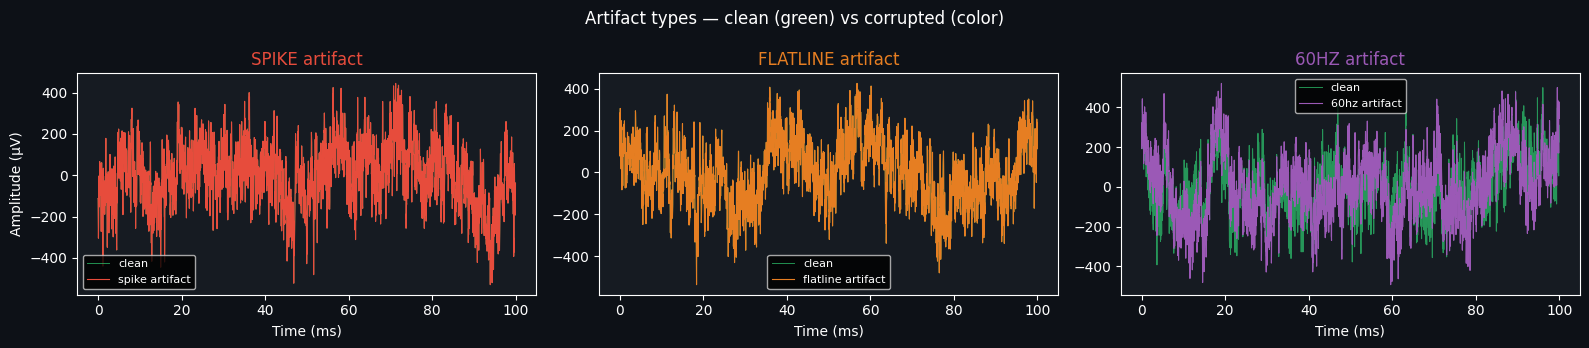

In [4]:
def find_first(atype):
    return next(i for i, t in enumerate(artifact_types) if t == atype)

fig, axes = plt.subplots(1, 3, figsize=(16, 3.5))
fig.patch.set_facecolor('#0d1117')
t_ms = np.arange(WINDOW_SAMPLES) / SAMPLE_RATE_HZ * 1000

for ax, atype, color in zip(axes, ['spike', 'flatline', '60hz'], ['#e74c3c', '#e67e22', '#9b59b6']):
    idx = find_first(atype)
    ax.plot(t_ms, clean[idx, DISPLAY_CH], color='#2ecc71', linewidth=0.7, label='clean', alpha=0.7)
    ax.plot(t_ms, corrupted_windows[idx][DISPLAY_CH], color=color, linewidth=0.8, label=f'{atype} artifact')
    ax.set_title(f'{atype.upper()} artifact', color=color, fontsize=12)
    ax.set_xlabel('Time (ms)')
    ax.set_facecolor('#161b22')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Amplitude (μV)')
fig.suptitle('Artifact types — clean (green) vs corrupted (color)', color='white', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Run both detectors across all windows

In [5]:
ours_results    = []
baseline_results = []

for w in range(N_WINDOWS):
    window = corrupted_windows[w]

    # MAD threshold 8.5: standard setting on realistic 1/f signal with harmonics.
    # Some weak 60Hz injections slip through; occasional borderline spikes may vary.
    mad_hit,  _ = detect_mad(window, threshold=8.5)
    hz60_hit, _ = detect_60hz(window)
    ours_hit    = mad_hit or hz60_hit

    base_hit, _ = detect_zscore(window)

    ours_results.append(ours_hit)
    baseline_results.append(base_hit)

def score(preds, truth):
    tp = sum(p and t for p, t in zip(preds, truth))
    fp = sum(p and not t for p, t in zip(preds, truth))
    fn = sum(not p and t for p, t in zip(preds, truth))
    precision = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
    recall    = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    return tp, fp, fn, precision, recall

ours_tp,  ours_fp,  ours_fn,  ours_prec,  ours_rec  = score(ours_results,   ground_truth)
base_tp,  base_fp,  base_fn,  base_prec,  base_rec  = score(baseline_results, ground_truth)

print(f"{'Detector':<25} {'TP':>5} {'FP':>5} {'FN':>5} {'Precision':>10} {'Recall':>8}")
print('-' * 60)
print(f"{'Ours (MAD+FFT)':<25} {ours_tp:>5} {ours_fp:>5} {ours_fn:>5} {ours_prec:>10.1%} {ours_rec:>8.1%}")
print(f"{'Z-score (baseline)':<25} {base_tp:>5} {base_fp:>5} {base_fn:>5} {base_prec:>10.1%} {base_rec:>8.1%}")
print()
print("Artifact breakdown:")
for atype in ['spike', 'flatline', '60hz']:
    idxs = [i for i, t in enumerate(artifact_types) if t == atype]
    if not idxs: continue
    ours_caught = sum(ours_results[i] for i in idxs)
    base_caught = sum(baseline_results[i] for i in idxs)
    print(f"  {atype:<10} — Ours: {ours_caught}/{len(idxs)}  Z-score: {base_caught}/{len(idxs)}")

Detector                     TP    FP    FN  Precision   Recall
------------------------------------------------------------
Ours (MAD+FFT)                5     0     3     100.0%    62.5%
Z-score (baseline)            1     1     7      50.0%    12.5%

Artifact breakdown:
  spike      — Ours: 1/1  Z-score: 1/1
  flatline   — Ours: 3/3  Z-score: 0/3
  60hz       — Ours: 1/4  Z-score: 0/4


## 5. Visual comparison — cleaned signal output

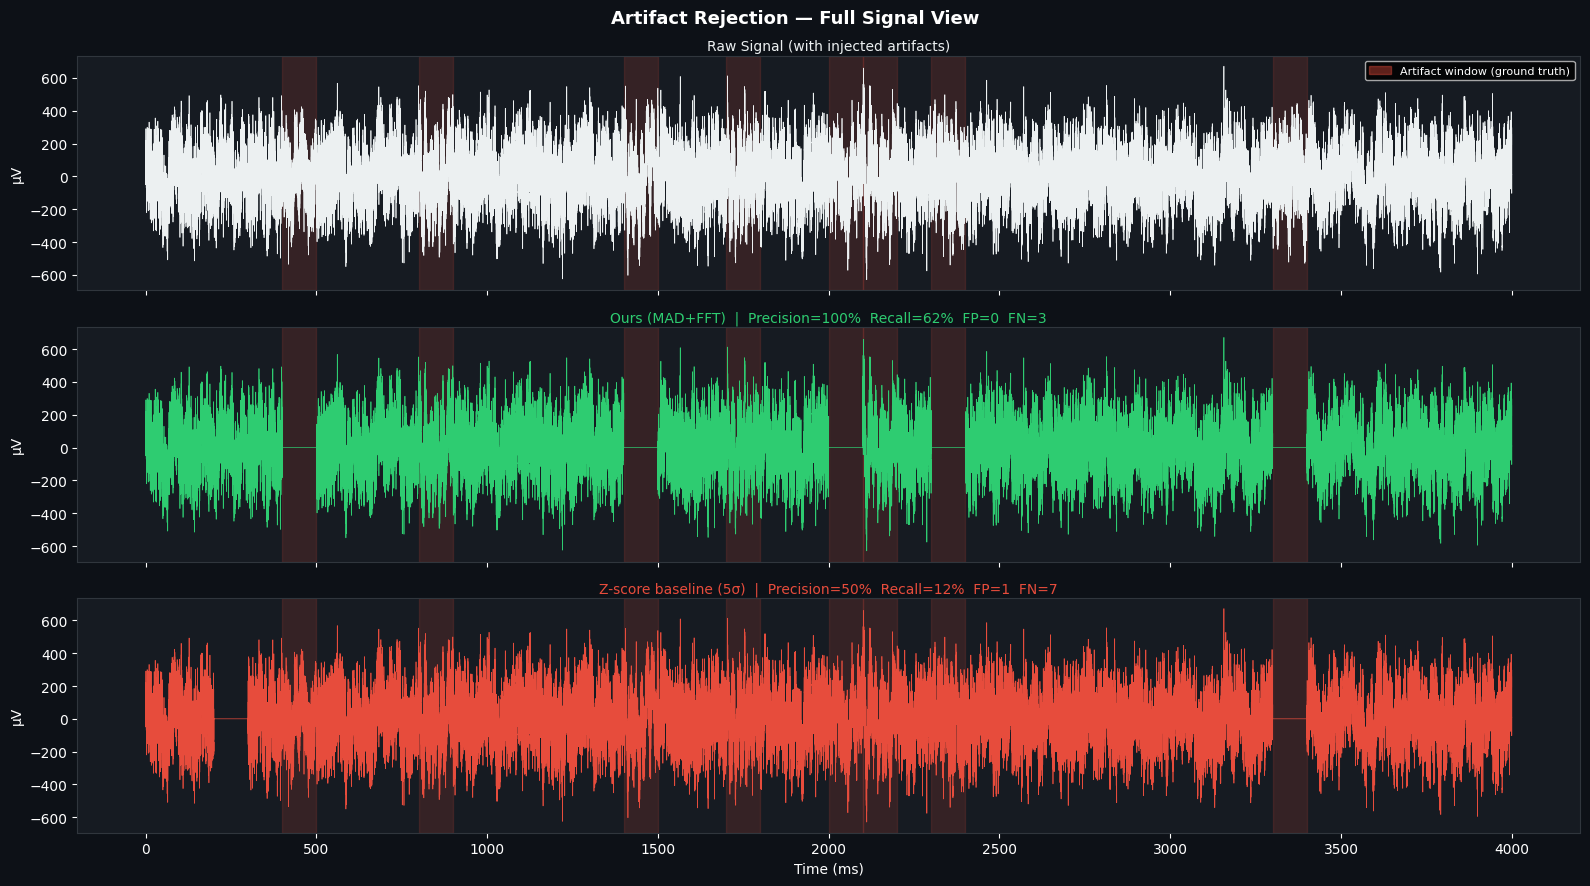

In [6]:
raw_signal    = np.concatenate([corrupted_windows[w][DISPLAY_CH] for w in range(N_WINDOWS)])
ours_cleaned  = np.concatenate([
    np.zeros(WINDOW_SAMPLES) if ours_results[w] else corrupted_windows[w][DISPLAY_CH]
    for w in range(N_WINDOWS)
])
base_cleaned  = np.concatenate([
    np.zeros(WINDOW_SAMPLES) if baseline_results[w] else corrupted_windows[w][DISPLAY_CH]
    for w in range(N_WINDOWS)
])

t_s = np.arange(len(raw_signal)) / SAMPLE_RATE_HZ * 1000  # ms

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Artifact Rejection — Full Signal View', color='white', fontsize=13, fontweight='bold')

panels = [
    (raw_signal,   '#ecf0f1', 'Raw Signal (with injected artifacts)'),
    (ours_cleaned, '#2ecc71', f'Ours (MAD+FFT)  |  Precision={ours_prec:.0%}  Recall={ours_rec:.0%}  FP={ours_fp}  FN={ours_fn}'),
    (base_cleaned, '#e74c3c', f'Z-score baseline (5σ)  |  Precision={base_prec:.0%}  Recall={base_rec:.0%}  FP={base_fp}  FN={base_fn}'),
]

for ax, (signal, color, title) in zip(axes, panels):
    ax.plot(t_s, signal, color=color, linewidth=0.5)
    ax.set_title(title, color=color, fontsize=10, pad=4)
    ax.set_facecolor('#161b22')
    ax.set_ylabel('μV')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')
    for w in range(N_WINDOWS):
        if ground_truth[w]:
            x0 = w * WINDOW_SAMPLES / SAMPLE_RATE_HZ * 1000
            x1 = x0 + WINDOW_SAMPLES / SAMPLE_RATE_HZ * 1000
            ax.axvspan(x0, x1, color='#e74c3c', alpha=0.15)

axes[-1].set_xlabel('Time (ms)')
patch = mpatches.Patch(color='#e74c3c', alpha=0.4, label='Artifact window (ground truth)')
axes[0].legend(handles=[patch], loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

## 6. Summary

The z-score baseline (5σ per channel) is a real approach used in BCI pipelines — not a straw man.
It still has fundamental blind spots:

- **Flatlines**: std → 0 means z-score is undefined. The flatlined channel is silently missed.
- **60 Hz line noise**: the artifact spreads energy uniformly across all 3000 samples, inflating σ
  while keeping individual z-scores low. Never flagged.
- **Masking**: broader artifacts inflate σ, suppressing the z-scores of the very samples they corrupt.

Our approach fixes each of these:
- **MAD replaces std**: the median is robust to outliers, so artifacts don't inflate the baseline.
  Flatlines are caught by the zero-MAD edge case.
- **FFT 60 Hz detector**: looks for spectral concentration at 60 Hz regardless of amplitude,
  catching noise the z-score detector is blind to.

In [7]:
ours_blanked = ours_results.count(True)
base_blanked = baseline_results.count(True)
real_artifacts = sum(ground_truth)

print(f'Windows blanked by our method:      {ours_blanked}/{N_WINDOWS}  ({ours_blanked/N_WINDOWS:.0%})')
print(f'Windows blanked by z-score:         {base_blanked}/{N_WINDOWS}  ({base_blanked/N_WINDOWS:.0%})')
print(f'Actual artifact windows:            {real_artifacts}/{N_WINDOWS}  ({real_artifacts/N_WINDOWS:.0%})')
print()
print(f'Clean signal preserved (ours):      {(N_WINDOWS - ours_blanked)/N_WINDOWS:.0%}')
print(f'Clean signal preserved (z-score):   {(N_WINDOWS - base_blanked)/N_WINDOWS:.0%}')
print()
print('Per-type breakdown:')
for atype in ['spike', 'flatline', '60hz']:
    idxs = [i for i, t in enumerate(artifact_types) if t == atype]
    if not idxs: continue
    ours_caught = sum(ours_results[i] for i in idxs)
    base_caught = sum(baseline_results[i] for i in idxs)
    print(f'  {atype:<10}  Ours: {ours_caught}/{len(idxs)}  Z-score: {base_caught}/{len(idxs)}')

Windows blanked by our method:      5/40  (12%)
Windows blanked by z-score:         2/40  (5%)
Actual artifact windows:            8/40  (20%)

Clean signal preserved (ours):      88%
Clean signal preserved (z-score):   95%

Per-type breakdown:
  spike       Ours: 1/1  Z-score: 1/1
  flatline    Ours: 3/3  Z-score: 0/3
  60hz        Ours: 1/4  Z-score: 0/4
